### Build a Basic Chatbot using Langgraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messsages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder=StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

In [7]:
## Compile the graph
graph = graph_builder.compile()

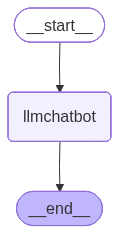

In [8]:
## Visualise the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages": "Hi"})

In [10]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [11]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?


### Chatbot with Tool

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is Tavily?")

{'query': 'What is Tavily?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@airabbitX/tavily-the-api-powered-alternative-to-perplexity-edfdc6814b39',
   'title': 'Tavily — The API-powered Alternative to Perplexity? | by AI Rabbit',
   'content': '# Tavily — The API-powered Alternative to Perplexity? Perplexity is yet another fascinating innovation in the AI space, and it has been around for a while now. It has managed to establish itself as a real and imho better alternative to Google (even Google AI) by offering more control over the search itself (like choosing the model, the depth of the AI search, and so on). Although Perplexity does have an API, it is mainly for AI LLM inference. In its simplest form, the API should simply answer questions using internet search and AI. > With GPT Researcher, you can do exactly what you would expect: AI-powered research using facts from the internet or even on-premise documents, powered by LL

In [13]:
## Custom function
def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a*b

In [14]:
tools=[tool, multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)

In [16]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DE1E51D150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DE1E678D10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

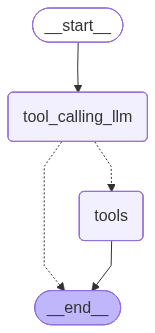

In [17]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## Compiling the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
response = graph.invoke({
    "messages": [("user", "What is the recent AI news in India?")]
})

In [29]:
response['messages'][-1].content

'{"query": "Recent AI news in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/27/indian-payments-chief-thinks-ai-will-be-heavily-involved-in-next-era-of-digital-payment-growth/", "title": "Indian payments chief thinks AI will be heavily involved in next era of digital payment growth - TechCrunch", "score": 0.7587435, "published_date": "Sun, 28 Jun 2026 05:00:00 GMT", "content": "# Indian payments chief thinks AI will be heavily involved in next era of digital payment growth. With an aim to reach over a billion daily transactions, Dilip Asbe, MD and CEO of the National Payments Corporation of India, which oversees UPI, thinks AI would be heavily involved in the next phase for user growth, fraud prevention, and credit distribution. During an interview with TechCrunch at Mumbai Tech Week (MTW) 2026 last month, Asbe said AI could drive the next half a billion users with NPCI, India’s central bank, and the government wor

In [30]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news in India?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (gcbdm3cjh)
 Call ID: gcbdm3cjh
  Args:
    query: Recent AI news in India
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI news in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/27/indian-payments-chief-thinks-ai-will-be-heavily-involved-in-next-era-of-digital-payment-growth/", "title": "Indian payments chief thinks AI will be heavily involved in next era of digital payment growth - TechCrunch", "score": 0.7587435, "published_date": "Sun, 28 Jun 2026 05:00:00 GMT", "content": "# Indian payments chief thinks AI will be heavily involved in next era of digital payment growth. With an 

In [26]:
response = graph.invoke({"messages":"What is 2 multiplied 3"})

In [27]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 3
================================== Ai Message ==================================
Tool Calls:
  multiply (9acc5x55w)
 Call ID: 9acc5x55w
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [32]:
response = graph.invoke({"messages":"Give me the recent AI news and mutliply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and mutliply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xm800163r)
 Call ID: xm800163r
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (yvt9rwcj7)
 Call ID: yvt9rwcj7
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-07-02/coreweave-junk-bonds-slide-further-as-investors-question-ai-boom", "title": "CoreWeave Junk Bonds Slide Further as Investors Question AI Boom - Bloomberg.com", "score": 0.6461259, "published_date": "Thu, 02 Jul 2026 16:24:58 GMT", "content": "are exposing what buyers in the credit market have been saying for a while: beneath t

### Adding memory in Agentic Graph

In [33]:
response = graph.invoke({"messages":"Hello my name is Umang!"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Umang!
================================== Ai Message ==================================

Hello Umang! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [34]:
response = graph.invoke({"messages":"What is my name ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name ?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have the ability to access personal data or recall previous conversations. If you'd like to share your name, I'd be happy to chat with you!


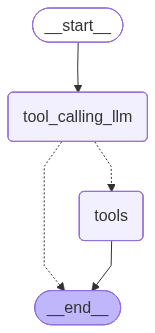

In [39]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver();

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## Compiling the graph
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
config={"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages": "Hi, my name is Umang"}, config=config)
response

{'messages': [HumanMessage(content='Hi, my name is Umang', additional_kwargs={}, response_metadata={}, id='083f260e-3847-4f3a-8dbf-2f05cbbea0cd'),
  AIMessage(content="Hello Umang! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1752, 'total_tokens': 1779, 'completion_time': 0.071938512, 'completion_tokens_details': None, 'prompt_time': 0.266202275, 'prompt_tokens_details': None, 'queue_time': 0.049646683, 'total_time': 0.338140787}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2840-c7fb-7133-b032-ec34a92fe18b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 27, 'total_tokens': 1779})]}

In [41]:
response['messages'][-1].content

"Hello Umang! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [42]:

response = graph.invoke({"messages": "What is my name?"}, config=config)
print(response['messages'][-1].content)

Your name is Umang.


### Streaming

In [43]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [44]:
def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

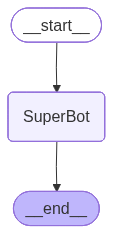

In [45]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [46]:
## Invocation

config = {"configurable" : {"thread_id" : "1"}}
graph_builder.invoke({'messages' : "Hi, my name is Krish and I like cricket"}, config)

{'messages': [HumanMessage(content='Hi, my name is Krish and I like cricket', additional_kwargs={}, response_metadata={}, id='e8a5f889-9eb1-41d9-a611-ca469e791a8b'),
  AIMessage(content='Hi Krish, nice to meet you. Cricket is an exciting sport with a huge following worldwide. Which team or player is your favorite? Are you a fan of international cricket, IPL, or do you enjoy playing the game yourself?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.180937026, 'completion_tokens_details': None, 'prompt_time': 0.00369763, 'prompt_tokens_details': None, 'queue_time': 0.530858627, 'total_time': 0.184634656}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f284a-380b-7700-9808-46ac25b48422-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

#### Streaming

Methods: stream() and astream()
- These methods are sync and async methods for streaming back results
 
Additional parameters in streaming modes for graph state
- values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called.

In [47]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config,
    stream_mode="updates"
):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Krish. Cricket is an exciting sport, and there are so many fans around the world who share your passion. Which team or player is your favorite? Are you more into the international test matches or the fast-paced T20 format?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.149975689, 'completion_tokens_details': None, 'prompt_time': 0.003717338, 'prompt_tokens_details': None, 'queue_time': 0.192490501, 'total_time': 0.153693027}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2853-5f9b-7b20-b9b1-cef25c6c3904-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 52, 'total_tokens': 97})]}}


In [48]:
for chunk in graph_builder.stream(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config,
    stream_mode="values"
):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='cb75edab-3788-45d4-a15b-358ab33b078b'), AIMessage(content='Nice to meet you, Krish. Cricket is an exciting sport, and there are so many fans around the world who share your passion. Which team or player is your favorite? Are you more into the international test matches or the fast-paced T20 format?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.149975689, 'completion_tokens_details': None, 'prompt_time': 0.003717338, 'prompt_tokens_details': None, 'queue_time': 0.192490501, 'total_time': 0.153693027}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2853-5f9b-7b20-b9b1-cef25c6c3904-0', tool_calls=[], invalid_tool_calls=[]

In [51]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config,
    stream_mode="updates"
):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you again, Krish. We already had a chat about your love for cricket, and you also mentioned that you enjoy football. Would you like to talk more about your favorite cricket teams, players, or tournaments? Or is there something else on your mind that you'd like to discuss? I'm all ears!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 276, 'total_tokens': 342, 'completion_time': 0.229296427, 'completion_tokens_details': None, 'prompt_time': 0.019454281, 'prompt_tokens_details': None, 'queue_time': 0.160913657, 'total_time': 0.248750708}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2855-8103-7d90-a094-aa3d519b94d9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 276, 'output_tokens': 66, 'total_tokens': 34

In [52]:
for chunk in graph_builder.stream(
    {"messages": "I also like Football"},
    config,
    stream_mode="values"
):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1de7312b-a410-446b-a04a-2c9f342f98f4'), AIMessage(content='Nice to meet you, Krish. Cricket is a fantastic sport, and there are so many exciting matches and players to follow. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test cricket, One-Day Internationals (ODIs), or Twenty20 (T20)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 45, 'total_tokens': 113, 'completion_time': 0.183662807, 'completion_tokens_details': None, 'prompt_time': 0.003973748, 'prompt_tokens_details': None, 'queue_time': 0.052233078, 'total_time': 0.187636555}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2854-3806-71a0-a046-69e80da37a61-0'